# Match Prediction With Rich Multi-Competition Team Form

This notebook trains a standalone football prediction pipeline across the
competitions in the merged rich stats dataset. The workflow: clean the data,
build leakage-safe pre-match features, train regularised models on past
fixtures, calibrate probabilities, tune the decision layer on a validation
window, and evaluate exactly once on a held-out future window.

The main match result is modeled as one multiclass 1X2 target
(`home_win`, `draw`, `away_win`), plus two binary XGBoost classifiers for
`home_wins_either_half` and `away_wins_either_half`.

Design choices that matter:

- **Three-way temporal split.** Train on the past, early-stop and tune every
  knob (hyperparameters, calibration, decision thresholds) on a recent
  validation window, then score the untouched test window once at the end.
- **Regularised XGBoost with early stopping** instead of library defaults,
  so train and test performance stay close.
- **Probability quality is first-class.** The decision layer acts on
  calibrated probabilities, so log-loss, baselines, and Platt calibration are
  reported alongside accuracy.
- **Missing-tolerant rich stats.** Expected-goals columns only exist from
  2023 onward; XGBoost routes missing values natively, so xG form features
  are used where available without dropping older rows.

Feature glossary (all built strictly from information available before kickoff):

| Group | Features | Meaning |
|---|---|---|
| Elo | `elo_difference`, `home_elo`, `away_elo` | Margin-of-victory Elo before this match: the gap and the absolute levels. |
| Short form (last 5) | `points_form_difference`, `goal_difference_form_gap`, `home_goals_scored_form`, `away_goals_scored_form`, `home_attack_vs_away_defence`, `away_attack_vs_home_defence` | Recent results and scoring form, cross-matched attack vs defence. |
| Short form (last 5) | `shots_on_target_difference`, `shots_on_target_conceded_difference`, `shot_accuracy_difference`, `corners_difference`, `possession_difference`, `fouls_difference` | Underlying match-stat form differences. |
| Venue form (last 5 at venue) | `home_points_at_home`, `away_points_at_away` | Points per game at the relevant venue. |
| Medium form (last 10) | `long_points_form_difference`, `long_goal_difference_form_gap` | Slower-moving form signal over a longer horizon. |
| Schedule | `rest_days_difference` | Days since each side's previous match, capped at 30 so off-season gaps do not act as outliers. |
| Context | `is_european_cup` | Whether the fixture is a UEFA cup tie rather than a domestic league match. |
| Head-to-head | `h2h_matches_played`, `h2h_home_win_rate`, `h2h_home_goal_difference` | Prior meetings between the two sides, from the home team's perspective. |
| Expected goals (last 5, missing-tolerant) | `home_xg_for_form`, `away_xg_for_form`, `home_xg_against_form`, `away_xg_against_form`, `home_finishing_luck_form`, `away_finishing_luck_form` | Rolling xG created and conceded, and goals minus xG (finishing over/under-performance). |

## 1. Imports and Constants

Every tunable lives here: windows, Elo settings, split dates, the regularised
XGBoost configuration, and the feature lists. Features are split into a core
set (a row must have all of them to be modelled) and a missing-tolerant set
(xG and head-to-head, which legitimately do not exist for every match).

In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import joblib
import numpy
import pandas
import matplotlib.pyplot as pyplot
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    log_loss,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

project_root = Path.cwd()
if not (project_root / "datasets").exists():
    project_root = project_root.parent

data_path = project_root / "datasets" / "rich_stats" / "league_matches_stats.csv"
models_directory = project_root / "models"
artifact_path = models_directory / "match_1x2_pred.joblib"

# Rolling-history windows.
short_window = 5
long_window = 10
long_window_minimum_matches = 5
xg_window = 5
xg_window_minimum_matches = 3
minimum_team_matches = 10
maximum_rest_days = 30.0

# Elo configuration.
initial_elo = 1500.0
elo_k = 20.0
home_advantage = 65.0

# Temporal splits: train on the past, tune everything on the validation
# window, and score the test window exactly once at the end.
validation_split_date = pandas.Timestamp("2025-07-01")
test_split_date = pandas.Timestamp("2026-01-01")

random_seed = 42

# Regularised XGBoost configuration. max_depth and min_child_weight are
# chosen from a small validation sweep in section 9; every model early-stops
# on validation log-loss instead of running to a fixed tree count.
xgboost_parameters = {
    "n_estimators": 600,
    "learning_rate": 0.05,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_lambda": 1.0,
    "tree_method": "hist",
    "early_stopping_rounds": 50,
    "n_jobs": -1,
    "random_state": random_seed,
}
max_depth_candidates = [3, 4, 5]
min_child_weight_candidates = [1, 5, 10]

european_cup_names = [
    "UEFA Champions League",
    "UEFA Europa League",
    "UEFA Conference League",
]

# Core features: a row must have every one of these to be modelled.
core_feature_names = [
    "elo_difference",
    "home_elo",
    "away_elo",
    "home_points_at_home",
    "away_points_at_away",
    "home_goals_scored_form",
    "away_goals_scored_form",
    "points_form_difference",
    "home_attack_vs_away_defence",
    "away_attack_vs_home_defence",
    "goal_difference_form_gap",
    "long_points_form_difference",
    "long_goal_difference_form_gap",
    "shots_on_target_difference",
    "shots_on_target_conceded_difference",
    "shot_accuracy_difference",
    "corners_difference",
    "possession_difference",
    "fouls_difference",
    "rest_days_difference",
    "is_european_cup",
    "h2h_matches_played",
]

# Missing-tolerant features: xG exists only from 2023 and head-to-head rates
# need a prior meeting. XGBoost handles the missing values natively.
nan_tolerant_feature_names = [
    "h2h_home_win_rate",
    "h2h_home_goal_difference",
    "home_xg_for_form",
    "away_xg_for_form",
    "home_xg_against_form",
    "away_xg_against_form",
    "home_finishing_luck_form",
    "away_finishing_luck_form",
]

feature_names = core_feature_names + nan_tolerant_feature_names

match_result_labels = {
    0: "home_win",
    1: "draw",
    2: "away_win",
}
binary_target_names = [
    "home_wins_either_half",
    "away_wins_either_half",
]
target_names = ["match_result"] + binary_target_names

required_raw_columns = [
    "match_id",
    "season",
    "country",
    "competition",
    "date_utc",
    "home_team",
    "away_team",
    "home_score_ft",
    "away_score_ft",
    "home_score_ht",
    "away_score_ht",
    "home_shots_on_target_ft",
    "away_shots_on_target_ft",
    "home_total_shots_ft",
    "away_total_shots_ft",
    "home_corner_kicks_ft",
    "away_corner_kicks_ft",
    "home_ball_possession_ft",
    "away_ball_possession_ft",
    "home_fouls_ft",
    "away_fouls_ft",
]
optional_raw_columns = [
    "home_expected_goals_ft",
    "away_expected_goals_ft",
]
raw_columns_used = required_raw_columns + optional_raw_columns

pandas.set_option("display.max_columns", 80)
pandas.set_option("display.max_rows", 80)

## 2. Load, Filter, Sort, and Derive Targets

Loads the merged rich stats file, keeps only rows with every required raw
column, and iteratively removes teams with fewer than ten matches. Expected
goals are loaded as optional columns: rows are kept even when xG is missing,
and the coverage-by-season table below shows why (xG starts in 2023).

In [2]:
def remove_matches_with_low_history_teams(match_frame, minimum_matches=minimum_team_matches):
    filtered_matches = match_frame.copy()
    filter_iterations = []

    while True:
        team_match_counts = pandas.concat([
            filtered_matches["home_team"],
            filtered_matches["away_team"],
        ]).value_counts()
        eligible_team_names = team_match_counts[team_match_counts >= minimum_matches].index
        next_filtered_matches = filtered_matches[
            filtered_matches["home_team"].isin(eligible_team_names)
            & filtered_matches["away_team"].isin(eligible_team_names)
        ].copy()

        filter_iterations.append({
            "iteration": len(filter_iterations) + 1,
            "matches_before": len(filtered_matches),
            "matches_after": len(next_filtered_matches),
            "teams_before": len(team_match_counts),
            "eligible_teams": len(eligible_team_names),
            "matches_removed": len(filtered_matches) - len(next_filtered_matches),
        })

        if len(next_filtered_matches) == len(filtered_matches):
            break
        filtered_matches = next_filtered_matches

    final_team_match_counts = pandas.concat([
        filtered_matches["home_team"],
        filtered_matches["away_team"],
    ]).value_counts()
    return filtered_matches, final_team_match_counts, pandas.DataFrame(filter_iterations)


def load_matches(path=data_path):
    matches = pandas.read_csv(path, usecols=raw_columns_used).copy()

    matches["date_utc"] = (
        pandas.to_datetime(matches["date_utc"], errors="coerce", utc=True)
        .dt.tz_convert(None)
    )

    numeric_raw_columns = [
        "home_score_ft",
        "away_score_ft",
        "home_score_ht",
        "away_score_ht",
        "home_shots_on_target_ft",
        "away_shots_on_target_ft",
        "home_total_shots_ft",
        "away_total_shots_ft",
        "home_corner_kicks_ft",
        "away_corner_kicks_ft",
        "home_ball_possession_ft",
        "away_ball_possession_ft",
        "home_fouls_ft",
        "away_fouls_ft",
    ] + optional_raw_columns
    for raw_column_name in numeric_raw_columns:
        matches[raw_column_name] = pandas.to_numeric(matches[raw_column_name], errors="coerce")

    rows_loaded = len(matches)
    matches = matches.dropna(subset=required_raw_columns).copy()
    rows_after_required_columns = len(matches)

    matches, team_match_counts, team_filter_summary = remove_matches_with_low_history_teams(matches)
    matches = matches.sort_values(["date_utc", "match_id"]).reset_index(drop=True)

    # Main 1X2 outcome and either-half labels.
    matches["home_win"] = (matches["home_score_ft"] > matches["away_score_ft"]).astype(int)
    matches["away_win"] = (matches["away_score_ft"] > matches["home_score_ft"]).astype(int)
    matches["draw"] = matches["home_score_ft"].eq(matches["away_score_ft"]).astype(int)
    matches["match_result"] = numpy.where(
        matches["home_win"].eq(1),
        0,
        numpy.where(matches["away_win"].eq(1), 2, 1),
    ).astype(int)

    home_second_half_goals = matches["home_score_ft"] - matches["home_score_ht"]
    away_second_half_goals = matches["away_score_ft"] - matches["away_score_ht"]
    matches["home_wins_either_half"] = (
        (matches["home_score_ht"] > matches["away_score_ht"])
        | (home_second_half_goals > away_second_half_goals)
    ).astype(int)
    matches["away_wins_either_half"] = (
        (matches["away_score_ht"] > matches["home_score_ht"])
        | (away_second_half_goals > home_second_half_goals)
    ).astype(int)

    matches["home_points"] = numpy.where(
        matches["home_win"].eq(1),
        3,
        numpy.where(matches["away_win"].eq(1), 0, 1),
    )
    matches["away_points"] = numpy.where(
        matches["away_win"].eq(1),
        3,
        numpy.where(matches["home_win"].eq(1), 0, 1),
    )

    matches["is_european_cup"] = matches["competition"].isin(european_cup_names).astype(int)

    load_summary = {
        "rows_loaded": rows_loaded,
        "rows_after_required_columns": rows_after_required_columns,
        "rows_after_team_filter": len(matches),
        "rows_removed_for_required_columns": rows_loaded - rows_after_required_columns,
        "rows_removed_for_low_history_teams": rows_after_required_columns - len(matches),
        "remaining_teams": len(team_match_counts),
        "minimum_remaining_team_matches": int(team_match_counts.min()) if len(team_match_counts) else 0,
    }
    return matches, team_match_counts, team_filter_summary, load_summary


matches, team_match_counts, team_filter_summary, load_summary = load_matches()

print("Cleaned dataset shape and date range")
print("Rows and columns:", matches.shape)
print("Data source:", data_path)
print("Date range:", matches["date_utc"].min().date(), "to", matches["date_utc"].max().date())

print("\nData loading and filtering summary")
display(pandas.DataFrame([load_summary]))

print("\n1X2 target distribution after cleaning")
display(
    matches["match_result"]
    .map(match_result_labels)
    .value_counts()
    .rename_axis("result")
    .rename("matches")
    .to_frame()
)

print("\nCompetition coverage after cleaning")
display(matches["competition"].value_counts().rename("matches").to_frame())

print("\nExpected-goals coverage by season (why xG features are missing-tolerant)")
display(
    matches.assign(has_expected_goals=matches["home_expected_goals_ft"].notna())
    .groupby("season")["has_expected_goals"]
    .mean()
    .rename("xg_coverage")
    .round(3)
    .to_frame()
)

print("\nLow-history team filter iterations")
display(team_filter_summary)

Cleaned dataset shape and date range
Rows and columns: (14721, 32)
Data source: C:\PROJECTS\Python\ML\betting\datasets\rich_stats\league_matches_stats.csv
Date range: 2020-08-18 to 2026-05-30

Data loading and filtering summary


,rows_loaded,rows_after_required_columns,rows_after_team_filter,rows_removed_for_required_columns,rows_removed_for_low_history_teams,remaining_teams,minimum_remaining_team_matches
0,15645,15627,14721,18,906,322,10



1X2 target distribution after cleaning


,matches
result,
home_win,6507
away_win,4640
draw,3574



Competition coverage after cleaning


,matches
competition,
Premier League,2280
La Liga,2280
Serie A,2280
Ligue 1,2067
Bundesliga,1841
UEFA Conference League,1361
UEFA Champions League,1334
UEFA Europa League,1278



Expected-goals coverage by season (why xG features are missing-tolerant)


,xg_coverage
season,
2020-2021,0.000
2021-2022,0.000
2022-2023,0.378
2023-2024,0.907
2024-2025,0.898
2025-2026,0.932



Low-history team filter iterations


,iteration,matches_before,matches_after,teams_before,eligible_teams,matches_removed
0,1,15627,14981,532,356,646
1,2,14981,14802,356,332,179
2,3,14802,14738,332,324,64
3,4,14738,14730,324,323,8
4,5,14730,14721,323,322,9
5,6,14721,14721,322,322,0


## 3. Elo Ratings With Margin-of-Victory Updates

Standard Elo, extended with a margin-of-victory multiplier: bigger wins move
ratings more, damped when the rating gap was already wide (so an elite side
thrashing a minnow is not over-rewarded). Each match records both teams'
pre-match ratings; the difference measures the gap, while the absolute
levels tell the model whether this is an elite pairing or a weak one, which
matters for draw rates.

In [3]:
def add_elo_features(match_frame, initial_elo_value=initial_elo, elo_k_value=elo_k, home_advantage_value=home_advantage):
    team_ratings = {}
    elo_records = []

    for match_record in match_frame.sort_values(["date_utc", "match_id"]).itertuples(index=False):
        home_rating = float(team_ratings.get(match_record.home_team, initial_elo_value))
        away_rating = float(team_ratings.get(match_record.away_team, initial_elo_value))

        expected_home_result = 1.0 / (
            1.0 + 10.0 ** (-((home_rating + home_advantage_value) - away_rating) / 400.0)
        )
        actual_home_result = 1.0 if match_record.home_win else 0.0 if match_record.away_win else 0.5

        # Margin-of-victory multiplier: log of the goal margin, damped by the
        # pre-match rating gap.
        goal_margin = abs(int(match_record.home_score_ft) - int(match_record.away_score_ft))
        margin_multiplier = numpy.log(max(goal_margin, 1) + 1) * (
            2.2 / (abs(home_rating - away_rating) * 0.001 + 2.2)
        )
        rating_change = elo_k_value * margin_multiplier * (actual_home_result - expected_home_result)

        elo_records.append({
            "match_id": match_record.match_id,
            "home_elo": home_rating,
            "away_elo": away_rating,
            "elo_difference": home_rating - away_rating,
        })

        team_ratings[match_record.home_team] = home_rating + rating_change
        team_ratings[match_record.away_team] = away_rating - rating_change

    matches_with_elo = match_frame.merge(pandas.DataFrame(elo_records), on="match_id", how="left")
    matches_with_elo = matches_with_elo.sort_values(["date_utc", "match_id"]).reset_index(drop=True)
    return matches_with_elo, dict(team_ratings)

## 4. Team-Perspective Rows and Rolling Form

Each match becomes two team-perspective rows. Rolling form uses
`closed="left"` everywhere so the current match never leaks into its own
features. Three horizons are used: a 5-match window for standard stats, a
10-match window (minimum 5) for slower-moving points and goal-difference
form, and a missing-tolerant 5-match window (minimum 3 observed values) for
xG. Rest days are capped so off-season gaps do not act as outliers.

In [4]:
def divide_safely(numerator, denominator):
    denominator_as_array = numpy.asarray(denominator, dtype=float)
    numerator_as_array = numpy.asarray(numerator, dtype=float)
    return numpy.divide(
        numerator_as_array,
        denominator_as_array,
        out=numpy.zeros_like(numerator_as_array, dtype=float),
        where=denominator_as_array != 0,
    )


def make_team_match_rows(match_frame):
    perspective_frames = []
    for venue_name, own_prefix, opponent_prefix in [("home", "home", "away"), ("away", "away", "home")]:
        perspective_frames.append(pandas.DataFrame({
            "match_id": match_frame["match_id"],
            "season": match_frame["season"],
            "date_utc": match_frame["date_utc"],
            "team": match_frame[f"{own_prefix}_team"],
            "opponent": match_frame[f"{opponent_prefix}_team"],
            "venue": venue_name,
            "goals_scored": match_frame[f"{own_prefix}_score_ft"],
            "goals_conceded": match_frame[f"{opponent_prefix}_score_ft"],
            "points": match_frame[f"{own_prefix}_points"],
            "shots_on_target": match_frame[f"{own_prefix}_shots_on_target_ft"],
            "shots_on_target_conceded": match_frame[f"{opponent_prefix}_shots_on_target_ft"],
            "shot_accuracy": divide_safely(
                match_frame[f"{own_prefix}_shots_on_target_ft"],
                match_frame[f"{own_prefix}_total_shots_ft"],
            ),
            "corners": match_frame[f"{own_prefix}_corner_kicks_ft"],
            "possession": match_frame[f"{own_prefix}_ball_possession_ft"],
            "fouls": match_frame[f"{own_prefix}_fouls_ft"],
            "expected_goals_for": match_frame[f"{own_prefix}_expected_goals_ft"],
            "expected_goals_against": match_frame[f"{opponent_prefix}_expected_goals_ft"],
        }))

    team_match_rows = pandas.concat(perspective_frames, ignore_index=True)
    team_match_rows["goal_difference"] = (
        team_match_rows["goals_scored"] - team_match_rows["goals_conceded"]
    )
    team_match_rows["result"] = team_match_rows["points"].map({3: 1.0, 1: 0.5, 0: 0.0})
    team_match_rows["finishing_luck"] = (
        team_match_rows["goals_scored"] - team_match_rows["expected_goals_for"]
    )
    return team_match_rows.sort_values(["team", "date_utc", "match_id"]).reset_index(drop=True)


short_rolling_metric_names = [
    "points",
    "goals_scored",
    "goals_conceded",
    "shots_on_target",
    "shots_on_target_conceded",
    "shot_accuracy",
    "corners",
    "possession",
    "fouls",
    "goal_difference",
]
long_rolling_metric_names = ["points", "goal_difference"]
xg_rolling_metric_names = ["expected_goals_for", "expected_goals_against", "finishing_luck"]

form_column_names = (
    [f"rolling_{metric_name}" for metric_name in short_rolling_metric_names]
    + [f"long_rolling_{metric_name}" for metric_name in long_rolling_metric_names]
    + [f"rolling_{metric_name}" for metric_name in xg_rolling_metric_names]
    + ["rolling_points_at_venue", "rest_days"]
)


def add_rolling_team_form(team_match_rows):
    # All-venue form for each team, excluding the current match.
    team_form_parts = []
    for _, team_history in team_match_rows.groupby("team", sort=False):
        ordered_team_history = team_history.sort_values(["date_utc", "match_id"]).copy()
        for metric_name in short_rolling_metric_names:
            ordered_team_history[f"rolling_{metric_name}"] = (
                ordered_team_history[metric_name]
                .rolling(short_window, closed="left")
                .mean()
            )
        for metric_name in long_rolling_metric_names:
            ordered_team_history[f"long_rolling_{metric_name}"] = (
                ordered_team_history[metric_name]
                .rolling(long_window, min_periods=long_window_minimum_matches, closed="left")
                .mean()
            )
        for metric_name in xg_rolling_metric_names:
            ordered_team_history[f"rolling_{metric_name}"] = (
                ordered_team_history[metric_name]
                .rolling(xg_window, min_periods=xg_window_minimum_matches, closed="left")
                .mean()
            )
        ordered_team_history["rest_days"] = (
            ordered_team_history["date_utc"].diff().dt.days.clip(upper=maximum_rest_days)
        )
        team_form_parts.append(ordered_team_history)

    team_form_with_all_venues = pandas.concat(team_form_parts, ignore_index=True)

    # Venue-specific points form, again excluding the current match.
    venue_form_parts = []
    for _, venue_history in team_form_with_all_venues.groupby(["team", "venue"], sort=False):
        ordered_venue_history = venue_history.sort_values(["date_utc", "match_id"]).copy()
        ordered_venue_history["rolling_points_at_venue"] = (
            ordered_venue_history["points"]
            .rolling(short_window, closed="left")
            .mean()
        )
        venue_form_parts.append(ordered_venue_history)

    team_form = pandas.concat(venue_form_parts, ignore_index=True)
    return team_form.sort_values(["date_utc", "match_id", "venue"]).reset_index(drop=True)

## 5. Head-to-Head Features

For every ordered pair (team, opponent) the expanding history of previous
meetings at either venue is summarised from the home team's perspective:
how many prior meetings exist, the home team's win rate (win = 1, draw = 0.5),
and the average goal difference. The `shift(1)` before the expanding mean
guarantees the current match never counts itself.

In [5]:
def add_head_to_head_features(match_frame, team_match_rows):
    ordered_pair_rows = team_match_rows.sort_values(["team", "opponent", "date_utc", "match_id"]).copy()
    pair_history = ordered_pair_rows.groupby(["team", "opponent"], sort=False)

    ordered_pair_rows["h2h_matches_played"] = pair_history.cumcount()
    ordered_pair_rows["h2h_win_rate"] = pair_history["result"].transform(
        lambda series: series.shift(1).expanding(min_periods=1).mean()
    )
    ordered_pair_rows["h2h_goal_difference"] = pair_history["goal_difference"].transform(
        lambda series: series.shift(1).expanding(min_periods=1).mean()
    )

    home_perspective_h2h = ordered_pair_rows[[
        "match_id",
        "team",
        "opponent",
        "h2h_matches_played",
        "h2h_win_rate",
        "h2h_goal_difference",
    ]].rename(columns={
        "team": "home_team",
        "opponent": "away_team",
        "h2h_win_rate": "h2h_home_win_rate",
        "h2h_goal_difference": "h2h_home_goal_difference",
    })

    return match_frame.merge(
        home_perspective_h2h,
        on=["match_id", "home_team", "away_team"],
        how="left",
    )

## 6. Assemble Feature Table

Merges Elo, rolling form for both sides, and head-to-head onto the match
table, then derives the named model features. Rows are only dropped when a
**core** feature is missing (a team without five prior matches); missing xG
or head-to-head values are kept and reported below.

In [6]:
def build_feature_table(match_frame):
    matches_with_elo, final_team_ratings = add_elo_features(match_frame)
    team_match_rows = make_team_match_rows(matches_with_elo)
    rolling_team_form = add_rolling_team_form(team_match_rows)
    feature_table = add_head_to_head_features(matches_with_elo, team_match_rows)

    for side_name in ["home", "away"]:
        side_form = rolling_team_form[rolling_team_form["venue"].eq(side_name)][
            ["match_id"] + form_column_names
        ].rename(columns={column_name: f"{side_name}_{column_name}" for column_name in form_column_names})
        feature_table = feature_table.merge(side_form, on="match_id", how="left")

    # Venue and scoring form.
    feature_table["home_points_at_home"] = feature_table["home_rolling_points_at_venue"]
    feature_table["away_points_at_away"] = feature_table["away_rolling_points_at_venue"]
    feature_table["home_goals_scored_form"] = feature_table["home_rolling_goals_scored"]
    feature_table["away_goals_scored_form"] = feature_table["away_rolling_goals_scored"]

    # Cross-matched form differences over the short window.
    feature_table["points_form_difference"] = (
        feature_table["home_rolling_points"] - feature_table["away_rolling_points"]
    )
    feature_table["home_attack_vs_away_defence"] = (
        feature_table["home_rolling_goals_scored"] - feature_table["away_rolling_goals_conceded"]
    )
    feature_table["away_attack_vs_home_defence"] = (
        feature_table["away_rolling_goals_scored"] - feature_table["home_rolling_goals_conceded"]
    )
    feature_table["goal_difference_form_gap"] = (
        feature_table["home_rolling_goal_difference"] - feature_table["away_rolling_goal_difference"]
    )
    feature_table["shots_on_target_difference"] = (
        feature_table["home_rolling_shots_on_target"] - feature_table["away_rolling_shots_on_target"]
    )
    feature_table["shots_on_target_conceded_difference"] = (
        feature_table["home_rolling_shots_on_target_conceded"]
        - feature_table["away_rolling_shots_on_target_conceded"]
    )
    feature_table["shot_accuracy_difference"] = (
        feature_table["home_rolling_shot_accuracy"] - feature_table["away_rolling_shot_accuracy"]
    )
    feature_table["corners_difference"] = (
        feature_table["home_rolling_corners"] - feature_table["away_rolling_corners"]
    )
    feature_table["possession_difference"] = (
        feature_table["home_rolling_possession"] - feature_table["away_rolling_possession"]
    )
    feature_table["fouls_difference"] = (
        feature_table["home_rolling_fouls"] - feature_table["away_rolling_fouls"]
    )
    feature_table["rest_days_difference"] = (
        feature_table["home_rest_days"] - feature_table["away_rest_days"]
    )

    # Slower-moving form over the long window.
    feature_table["long_points_form_difference"] = (
        feature_table["home_long_rolling_points"] - feature_table["away_long_rolling_points"]
    )
    feature_table["long_goal_difference_form_gap"] = (
        feature_table["home_long_rolling_goal_difference"]
        - feature_table["away_long_rolling_goal_difference"]
    )

    # Missing-tolerant xG form.
    feature_table["home_xg_for_form"] = feature_table["home_rolling_expected_goals_for"]
    feature_table["away_xg_for_form"] = feature_table["away_rolling_expected_goals_for"]
    feature_table["home_xg_against_form"] = feature_table["home_rolling_expected_goals_against"]
    feature_table["away_xg_against_form"] = feature_table["away_rolling_expected_goals_against"]
    feature_table["home_finishing_luck_form"] = feature_table["home_rolling_finishing_luck"]
    feature_table["away_finishing_luck_form"] = feature_table["away_rolling_finishing_luck"]

    return feature_table, team_match_rows, rolling_team_form, final_team_ratings


feature_table, team_match_rows, rolling_team_form, final_team_ratings = build_feature_table(matches)
model_data = feature_table.dropna(subset=core_feature_names).copy()

print("Feature build summary")
display(pandas.DataFrame([{
    "rows_before_dropping_no_history_rows": len(feature_table),
    "rows_after_dropping_no_history_rows": len(model_data),
    "rows_dropped": len(feature_table) - len(model_data),
    "core_features": len(core_feature_names),
    "missing_tolerant_features": len(nan_tolerant_feature_names),
    "total_features": len(feature_names),
}]))

print("\nMissing-tolerant feature availability (share of modelled rows with a value)")
display(
    model_data[nan_tolerant_feature_names]
    .notna()
    .mean()
    .rename("available")
    .round(3)
    .to_frame()
)

print("\nModeling table preview")
display(
    model_data[
        ["season", "competition", "date_utc", "home_team", "away_team"]
        + target_names
        + feature_names
    ].head()
)

Feature build summary


,rows_before_dropping_no_history_rows,rows_after_dropping_no_history_rows,rows_dropped,core_features,missing_tolerant_features,total_features
0,14721,12475,2246,22,8,30



Missing-tolerant feature availability (share of modelled rows with a value)


,available
h2h_home_win_rate,0.824
h2h_home_goal_difference,0.824
home_xg_for_form,0.581
away_xg_for_form,0.582
home_xg_against_form,0.581
away_xg_against_form,0.582
home_finishing_luck_form,0.581
away_finishing_luck_form,0.582



Modeling table preview


,season,competition,date_utc,home_team,away_team,match_result,home_wins_either_half,away_wins_either_half,elo_difference,home_elo,away_elo,home_points_at_home,away_points_at_away,home_goals_scored_form,away_goals_scored_form,points_form_difference,home_attack_vs_away_defence,away_attack_vs_home_defence,goal_difference_form_gap,long_points_form_difference,long_goal_difference_form_gap,shots_on_target_difference,shots_on_target_conceded_difference,shot_accuracy_difference,corners_difference,possession_difference,fouls_difference,rest_days_difference,is_european_cup,h2h_matches_played,h2h_home_win_rate,h2h_home_goal_difference,home_xg_for_form,away_xg_for_form,home_xg_against_form,away_xg_against_form,home_finishing_luck_form,away_finishing_luck_form
548,2020-2021,UEFA Europa League,2020-11-05 20:00:00,ac_milan,lille,2,0,1,20.738357,1579.115532,1558.377175,2.6,2.2,2.6,2.4,0.8,1.6,1.2,0.0,0.6,0.3,0.2,2.0,0.213888,-3.4,-3.8,1.4,0.0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
577,2020-2021,Ligue 1,2020-11-07 20:00:00,psg,rennes,0,1,0,53.058153,1569.541028,1516.482876,1.8,1.4,2.2,0.8,1.0,0.6,0.0,2.2,0.9,2.0,0.8,-0.6,-0.092199,1.6,1.6,-0.6,0.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
591,2020-2021,La Liga,2020-11-08 15:15:00,real_sociedad,granada_cf,0,1,0,19.446570,1561.667485,1542.220914,1.8,2.6,2.0,1.2,0.2,1.6,0.6,0.6,0.1,1.2,2.8,-0.6,0.092720,5.2,15.6,-2.6,0.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
603,2020-2021,Ligue 1,2020-11-20 20:00:00,monaco,psg,0,1,1,-62.561086,1516.085964,1578.647050,2.2,2.4,1.6,2.6,-1.0,1.2,1.2,-2.0,-0.7,-2.1,0.6,0.2,-0.060791,5.2,7.4,0.2,-1.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
614,2020-2021,La Liga,2020-11-21 15:15:00,villarreal,real_madrid,1,1,1,33.106964,1559.615307,1526.508342,3.0,2.0,2.4,2.6,0.6,0.4,2.2,1.4,0.4,0.6,-1.2,-1.8,0.023309,-2.0,2.8,-2.2,1.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Train / Validation / Test Split

Three temporal windows. The validation window is used for early stopping,
the hyperparameter sweep, probability calibration, and decision-threshold
tuning. The test window is scored exactly once, in section 13.

In [7]:
training_matches = model_data[model_data["date_utc"] < validation_split_date].copy()
validation_matches = model_data[
    (model_data["date_utc"] >= validation_split_date)
    & (model_data["date_utc"] < test_split_date)
].copy()
test_matches = model_data[model_data["date_utc"] >= test_split_date].copy()


def result_rate(frame, result_code):
    return float(frame["match_result"].eq(result_code).mean()) if len(frame) else numpy.nan


split_summary = pandas.DataFrame([
    {
        "split": split_name,
        "rows": len(split_frame),
        "start": split_frame["date_utc"].min().date(),
        "end": split_frame["date_utc"].max().date(),
        "home_win_rate": result_rate(split_frame, 0),
        "draw_rate": result_rate(split_frame, 1),
        "away_win_rate": result_rate(split_frame, 2),
        "home_wins_either_half_rate": split_frame["home_wins_either_half"].mean(),
        "away_wins_either_half_rate": split_frame["away_wins_either_half"].mean(),
    }
    for split_name, split_frame in [
        ("training", training_matches),
        ("validation", validation_matches),
        ("test", test_matches),
    ]
])

print("Temporal three-way split summary")
print(f"Validation from {validation_split_date.date()}, test from {test_split_date.date()}")
display(split_summary.round(3))

training_feature_matrix = training_matches[feature_names]
validation_feature_matrix = validation_matches[feature_names]
test_feature_matrix = test_matches[feature_names]

Temporal three-way split summary
Validation from 2025-07-01, test from 2026-01-01


,split,rows,start,end,home_win_rate,draw_rate,away_win_rate,home_wins_either_half_rate,away_wins_either_half_rate
0,training,10072,2020-11-05,2025-05-31,0.439,0.246,0.315,0.579,0.469
1,validation,1251,2025-07-08,2025-12-30,0.474,0.225,0.301,0.595,0.432
2,test,1152,2026-01-01,2026-05-30,0.439,0.248,0.312,0.585,0.458


## 8. Baselines

Two reference points the full model has to beat on probability quality:

- **Class frequency**: always predict the training class distribution.
- **Elo-only logistic regression**: a one-feature multinomial model on
  `elo_difference`, the strongest single signal.

Both are evaluated on the validation window here and again on the test
window in the final evaluation.

In [8]:
def evaluate_multiclass_probabilities(outcome_labels, class_probabilities):
    class_probabilities = numpy.asarray(class_probabilities)
    return {
        "accuracy": accuracy_score(outcome_labels, class_probabilities.argmax(axis=1)),
        "log_loss": log_loss(outcome_labels, class_probabilities, labels=[0, 1, 2]),
    }


training_class_rates = (
    training_matches["match_result"].value_counts(normalize=True).sort_index().to_numpy()
)


def class_frequency_probabilities(row_count):
    return numpy.tile(training_class_rates, (row_count, 1))


elo_only_model = LogisticRegression(max_iter=1000, random_state=random_seed)
elo_only_model.fit(training_matches[["elo_difference"]], training_matches["match_result"])

validation_baseline_table = pandas.DataFrame([
    {
        "model": "class_frequency",
        **evaluate_multiclass_probabilities(
            validation_matches["match_result"],
            class_frequency_probabilities(len(validation_matches)),
        ),
    },
    {
        "model": "elo_only_logistic",
        **evaluate_multiclass_probabilities(
            validation_matches["match_result"],
            elo_only_model.predict_proba(validation_matches[["elo_difference"]]),
        ),
    },
])

print("1X2 baselines on the validation window")
display(validation_baseline_table.round(4))

1X2 baselines on the validation window


,model,accuracy,log_loss
0,class_frequency,0.4740,1.0534
1,elo_only_logistic,0.5396,0.9718


## 9. XGBoost Training With Early Stopping

A small sweep over `max_depth` and `min_child_weight`; every candidate
early-stops on validation log-loss, so tree count is chosen automatically.
The best 1X2 configuration (by validation log-loss) is reused for the two
either-half models. The metrics table shows train and validation together,
with the generalisation gap as the number to watch.

In [9]:
sweep_records = []
best_sweep_record = None
best_sweep_model = None

for max_depth_value in max_depth_candidates:
    for min_child_weight_value in min_child_weight_candidates:
        candidate_model = XGBClassifier(
            **xgboost_parameters,
            objective="multi:softprob",
            eval_metric="mlogloss",
            max_depth=max_depth_value,
            min_child_weight=min_child_weight_value,
        )
        candidate_model.fit(
            training_feature_matrix,
            training_matches["match_result"],
            eval_set=[(validation_feature_matrix, validation_matches["match_result"])],
            verbose=False,
        )
        sweep_record = {
            "max_depth": max_depth_value,
            "min_child_weight": min_child_weight_value,
            "best_iteration": int(candidate_model.best_iteration),
            **evaluate_multiclass_probabilities(
                validation_matches["match_result"],
                candidate_model.predict_proba(validation_feature_matrix),
            ),
        }
        sweep_records.append(sweep_record)
        if best_sweep_record is None or sweep_record["log_loss"] < best_sweep_record["log_loss"]:
            best_sweep_record = sweep_record
            best_sweep_model = candidate_model

sweep_table = pandas.DataFrame(sweep_records).sort_values("log_loss").reset_index(drop=True)
print("Validation sweep (sorted by validation log-loss)")
display(sweep_table.round(4))

best_max_depth = best_sweep_record["max_depth"]
best_min_child_weight = best_sweep_record["min_child_weight"]
print(f"\nSelected configuration: max_depth={best_max_depth}, min_child_weight={best_min_child_weight}, "
      f"best_iteration={best_sweep_record['best_iteration']}")

trained_models = {"match_result": best_sweep_model}
for target_name in binary_target_names:
    binary_model = XGBClassifier(
        **xgboost_parameters,
        eval_metric="logloss",
        max_depth=best_max_depth,
        min_child_weight=best_min_child_weight,
    )
    binary_model.fit(
        training_feature_matrix,
        training_matches[target_name],
        eval_set=[(validation_feature_matrix, validation_matches[target_name])],
        verbose=False,
    )
    trained_models[target_name] = binary_model


def collect_model_metrics(models_by_target, split_frames):
    metric_records = []
    for split_name, split_frame in split_frames.items():
        split_features = split_frame[feature_names]
        metric_records.append({
            "target": "match_result",
            "split": split_name,
            "rows": len(split_frame),
            **evaluate_multiclass_probabilities(
                split_frame["match_result"],
                models_by_target["match_result"].predict_proba(split_features),
            ),
        })
        for target_name in binary_target_names:
            positive_probabilities = models_by_target[target_name].predict_proba(split_features)[:, 1]
            metric_records.append({
                "target": target_name,
                "split": split_name,
                "rows": len(split_frame),
                "accuracy": accuracy_score(
                    split_frame[target_name],
                    (positive_probabilities >= 0.5).astype(int),
                ),
                "log_loss": log_loss(split_frame[target_name], positive_probabilities, labels=[0, 1]),
            })
    return pandas.DataFrame(metric_records)


model_metric_table = collect_model_metrics(
    trained_models,
    {"training": training_matches, "validation": validation_matches},
)

print("\nModel accuracy and log-loss by split")
display(
    model_metric_table
    .pivot(index="target", columns="split", values="accuracy")
    .round(3)
    .rename(columns=lambda name: f"{name}_accuracy")
    .join(
        model_metric_table
        .pivot(index="target", columns="split", values="log_loss")
        .round(3)
        .rename(columns=lambda name: f"{name}_log_loss")
    )
)

Validation sweep (sorted by validation log-loss)


,max_depth,min_child_weight,best_iteration,accuracy,log_loss
0,3,5,66,0.5420,0.9720
1,4,5,69,0.5452,0.9720
2,3,10,66,0.5420,0.9723
3,4,1,71,0.5468,0.9725
4,4,10,64,0.5444,0.9727
5,3,1,66,0.5436,0.9729
6,5,5,62,0.5412,0.9746
7,5,10,56,0.5444,0.9749
8,5,1,62,0.5444,0.9754



Selected configuration: max_depth=3, min_child_weight=5, best_iteration=66

Model accuracy and log-loss by split


split,training_accuracy,validation_accuracy,training_log_loss,validation_log_loss
target,,,,
away_wins_either_half,0.656,0.645,0.614,0.630
home_wins_either_half,0.665,0.648,0.606,0.623
match_result,0.542,0.542,0.963,0.972


## 10. Model Diagnostics (train vs validation)

Generalisation gap, validation confusion behaviour, class-level metrics, and
what the 1X2 model actually relies on. The test window stays untouched until
section 13.

Train/validation generalisation gap (accuracy)


split,training,validation,train_validation_gap
target,,,
home_wins_either_half,0.665,0.648,0.016
away_wins_either_half,0.656,0.645,0.011
match_result,0.542,0.542,-0.000


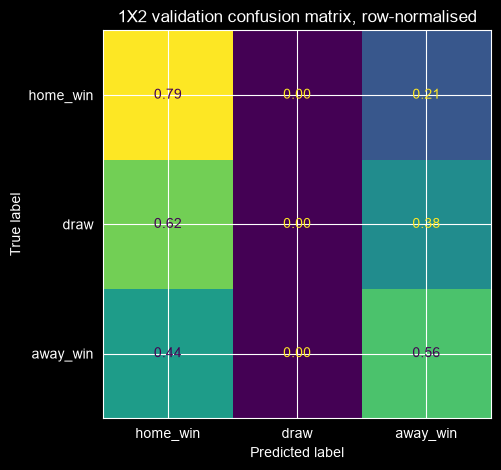

1X2 class-level validation metrics


,precision,recall,f1-score,support
home_win,0.580,0.786,0.667,593.000
draw,0.000,0.000,0.000,281.000
away_win,0.475,0.562,0.515,377.000
accuracy,0.542,0.542,0.542,0.542
macro avg,0.352,0.449,0.394,1251.000
weighted avg,0.418,0.542,0.471,1251.000


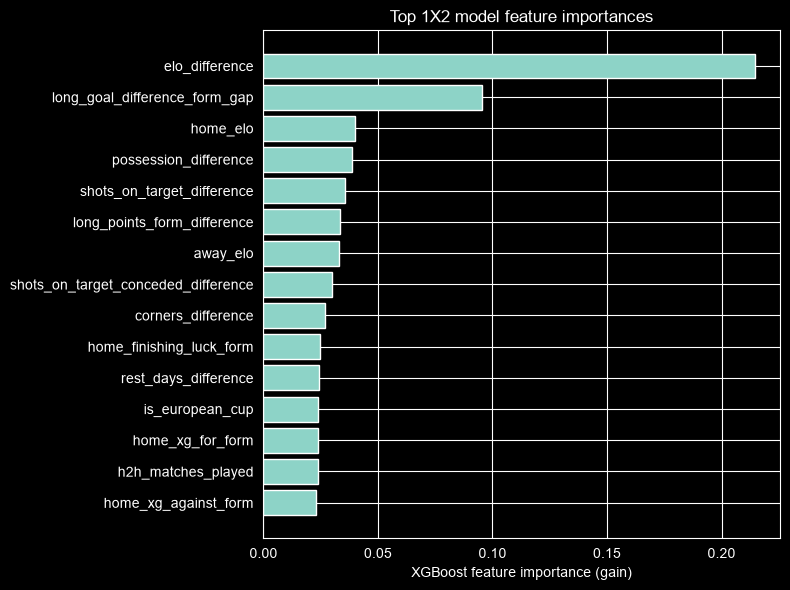

Top feature importances for the 1X2 model


,feature,importance
0,elo_difference,0.2148
1,long_goal_difference_form_gap,0.0952
2,home_elo,0.0401
3,possession_difference,0.0389
4,shots_on_target_difference,0.0357
5,long_points_form_difference,0.0336
6,away_elo,0.0328
7,shots_on_target_conceded_difference,0.0299
8,corners_difference,0.0269
9,home_finishing_luck_form,0.0249


In [10]:
accuracy_gap_table = (
    model_metric_table
    .pivot(index="target", columns="split", values="accuracy")
    .assign(train_validation_gap=lambda frame: frame["training"] - frame["validation"])
    .sort_values("train_validation_gap", ascending=False)
)
print("Train/validation generalisation gap (accuracy)")
display(accuracy_gap_table.round(3))

result_label_order = [match_result_labels[result_code] for result_code in [0, 1, 2]]
validation_result_predictions = (
    trained_models["match_result"].predict_proba(validation_feature_matrix).argmax(axis=1)
)

normalised_confusion = confusion_matrix(
    validation_matches["match_result"],
    validation_result_predictions,
    labels=[0, 1, 2],
    normalize="true",
)
confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=normalised_confusion,
    display_labels=result_label_order,
)
figure, axis = pyplot.subplots(figsize=(5.6, 4.8))
confusion_display.plot(ax=axis, values_format=".2f", colorbar=False)
axis.set_title("1X2 validation confusion matrix, row-normalised")
pyplot.tight_layout()
pyplot.show()

print("1X2 class-level validation metrics")
display(
    pandas.DataFrame(
        classification_report(
            validation_matches["match_result"],
            validation_result_predictions,
            labels=[0, 1, 2],
            target_names=result_label_order,
            output_dict=True,
            zero_division=0,
        )
    ).transpose().round(3)
)

feature_importance_table = (
    pandas.DataFrame({
        "feature": feature_names,
        "importance": trained_models["match_result"].feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

figure, axis = pyplot.subplots(figsize=(8, 6))
top_feature_importance = feature_importance_table.head(15).sort_values("importance")
axis.barh(top_feature_importance["feature"], top_feature_importance["importance"])
axis.set_title("Top 1X2 model feature importances")
axis.set_xlabel("XGBoost feature importance (gain)")
pyplot.tight_layout()
pyplot.show()

print("Top feature importances for the 1X2 model")
display(feature_importance_table.head(15).round(4))

## 11. Probability Calibration

The decision layer thresholds calibrated probabilities, so those
probabilities need to mean what they say. Platt scaling is fitted on the
validation window: a small multinomial logistic regression on the log of the raw class
probabilities for the 1X2 model, and a one-feature logistic regression on
the logit of the raw positive probability for each either-half model.

Platt scaling is chosen over isotonic regression because the validation
window has only ~1,200 matches. Isotonic can saturate extreme predictions to
exactly 0 and 1, which is fatal for a layer that bets on probability
thresholds. Platt is smooth and monotone and cannot saturate.

The before/after numbers below are measured on the same validation window
the calibrators were fitted on, so they are optimistic by construction. The
honest read-out is the test comparison in section 13.

1X2 validation log-loss before and after calibration (in-sample for the calibrators)


,probabilities,accuracy,log_loss
0,raw,0.5420,0.9720
1,calibrated,0.5436,0.9678


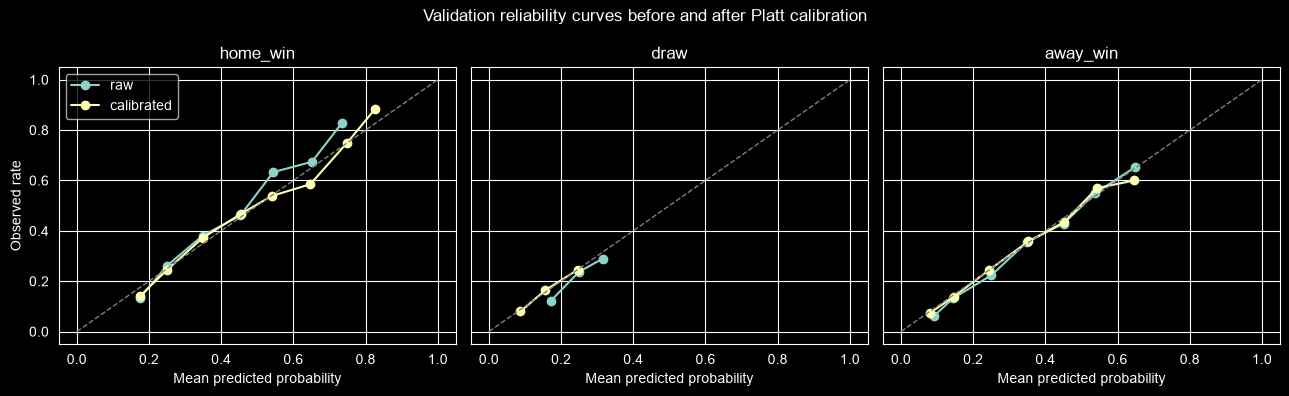

In [11]:
def log_probability_features(class_probabilities):
    return numpy.log(numpy.clip(numpy.asarray(class_probabilities), 1e-6, 1.0))


def logit_feature(positive_probabilities):
    clipped = numpy.clip(numpy.asarray(positive_probabilities), 1e-6, 1.0 - 1e-6)
    return numpy.log(clipped / (1.0 - clipped)).reshape(-1, 1)


raw_validation_probabilities = trained_models["match_result"].predict_proba(validation_feature_matrix)

match_result_calibrator = LogisticRegression(max_iter=1000, random_state=random_seed)
match_result_calibrator.fit(
    log_probability_features(raw_validation_probabilities),
    validation_matches["match_result"],
)


def apply_match_result_calibration(raw_probabilities, calibrator=None):
    if calibrator is None:
        calibrator = match_result_calibrator
    return calibrator.predict_proba(log_probability_features(raw_probabilities))


either_half_calibrators = {}
for target_name in binary_target_names:
    raw_positive_probabilities = trained_models[target_name].predict_proba(validation_feature_matrix)[:, 1]
    binary_calibrator = LogisticRegression(max_iter=1000, random_state=random_seed)
    binary_calibrator.fit(
        logit_feature(raw_positive_probabilities),
        validation_matches[target_name],
    )
    either_half_calibrators[target_name] = binary_calibrator


def apply_binary_calibration(raw_positive_probabilities, calibrator):
    return calibrator.predict_proba(logit_feature(raw_positive_probabilities))[:, 1]


calibrated_validation_probabilities = apply_match_result_calibration(raw_validation_probabilities)

print("1X2 validation log-loss before and after calibration (in-sample for the calibrators)")
display(pandas.DataFrame([
    {"probabilities": "raw", **evaluate_multiclass_probabilities(validation_matches["match_result"], raw_validation_probabilities)},
    {"probabilities": "calibrated", **evaluate_multiclass_probabilities(validation_matches["match_result"], calibrated_validation_probabilities)},
]).round(4))


def reliability_table(predicted_probabilities, outcome_indicator, number_of_bins=10, minimum_bin_size=25):
    bin_edges = numpy.linspace(0.0, 1.0, number_of_bins + 1)
    bin_ids = numpy.clip(numpy.digitize(predicted_probabilities, bin_edges) - 1, 0, number_of_bins - 1)
    bin_records = []
    for bin_id in range(number_of_bins):
        in_bin = bin_ids == bin_id
        if in_bin.sum() >= minimum_bin_size:
            bin_records.append({
                "mean_predicted": float(predicted_probabilities[in_bin].mean()),
                "observed_rate": float(outcome_indicator[in_bin].mean()),
                "matches": int(in_bin.sum()),
            })
    return pandas.DataFrame(bin_records)


figure, axes = pyplot.subplots(1, 3, figsize=(13, 4), sharey=True)
for class_code, axis in zip([0, 1, 2], axes):
    outcome_indicator = validation_matches["match_result"].eq(class_code).astype(float).to_numpy()
    for curve_label, probability_values in [
        ("raw", raw_validation_probabilities[:, class_code]),
        ("calibrated", calibrated_validation_probabilities[:, class_code]),
    ]:
        curve_table = reliability_table(probability_values, outcome_indicator)
        axis.plot(curve_table["mean_predicted"], curve_table["observed_rate"], marker="o", label=curve_label)
    axis.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    axis.set_title(match_result_labels[class_code])
    axis.set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Observed rate")
axes[0].legend()
figure.suptitle("Validation reliability curves before and after Platt calibration")
pyplot.tight_layout()
pyplot.show()

## 12. Decision Layer and Threshold Tuning

The decision layer abstains unless a pick clears calibrated confidence
rules. It selects an outright winner when the calibrated probability and
its margin over the runner-up are high enough, falls back to an
either-half pick when that clears its own threshold, and otherwise skips.
The three thresholds are selected from a validation-window grid by best
combined precision, subject to a minimum
coverage floor.

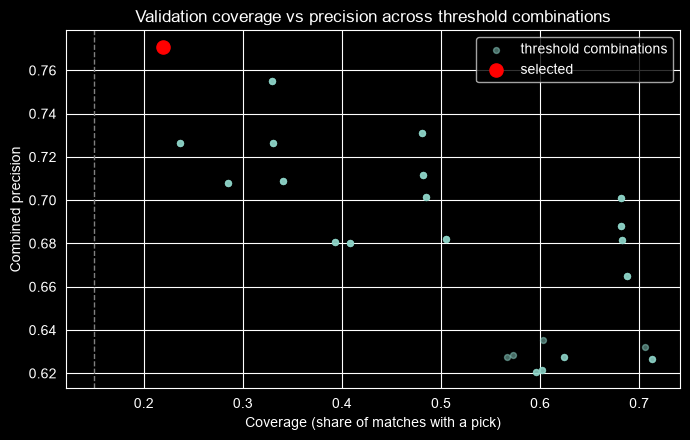

Top threshold combinations by validation precision (coverage floor 15%)


,minimum_outright_probability,minimum_outright_margin,minimum_either_half_probability,picks,coverage,precision
67,0.7,0.10,0.75,275,0.220,0.771
71,0.7,0.15,0.75,275,0.220,0.771
75,0.7,0.20,0.75,275,0.220,0.771
79,0.7,0.25,0.75,275,0.220,0.771
66,0.7,0.10,0.70,412,0.329,0.755
70,0.7,0.15,0.70,412,0.329,0.755
74,0.7,0.20,0.70,412,0.329,0.755
78,0.7,0.25,0.70,412,0.329,0.755
65,0.7,0.10,0.65,602,0.481,0.731
69,0.7,0.15,0.65,602,0.481,0.731



Selected decision thresholds: {'minimum_outright_probability': 0.7, 'minimum_outright_margin': 0.1, 'minimum_either_half_probability': 0.75}

Validation decision summary with the selected thresholds


,decision,picks,coverage,precision
0,home,188,0.150,0.787
1,away,7,0.006,0.857
2,home win either half,47,0.038,0.766
3,away win either half,33,0.026,0.667
4,combined slate,275,0.220,0.771
5,skip,976,0.780,NaN


In [12]:
decision_labels = [
    "home",
    "away",
    "home win either half",
    "away win either half",
    "skip",
]


def predict_match_result_probabilities(match_result_model, feature_matrix, calibrated=True):
    probabilities = match_result_model.predict_proba(feature_matrix)
    if calibrated:
        probabilities = apply_match_result_calibration(probabilities)
    probability_frame = pandas.DataFrame(index=feature_matrix.index)
    for class_position, class_label in enumerate(match_result_model.classes_):
        result_name = match_result_labels[int(class_label)]
        probability_frame[f"{result_name}_probability"] = probabilities[:, class_position]
    return probability_frame


def score_model_probabilities(match_frame, models_by_target, calibrated=True):
    scored_matches = match_frame[[
        "season",
        "country",
        "competition",
        "date_utc",
        "home_team",
        "away_team",
        "match_result",
        "home_win",
        "draw",
        "away_win",
        "home_wins_either_half",
        "away_wins_either_half",
    ]].copy()
    feature_matrix = match_frame[feature_names]

    scored_matches = scored_matches.join(
        predict_match_result_probabilities(
            models_by_target["match_result"],
            feature_matrix,
            calibrated=calibrated,
        )
    )
    for target_name in binary_target_names:
        positive_probabilities = models_by_target[target_name].predict_proba(feature_matrix)[:, 1]
        if calibrated:
            positive_probabilities = apply_binary_calibration(
                positive_probabilities,
                either_half_calibrators[target_name],
            )
        scored_matches[f"{target_name}_probability"] = positive_probabilities
    return scored_matches.reset_index(drop=True)


def make_decision(
    home_win_probability,
    draw_probability,
    away_win_probability,
    home_wins_either_half_probability,
    away_wins_either_half_probability,
    thresholds,
):
    result_probabilities = {
        "home": home_win_probability,
        "draw": draw_probability,
        "away": away_win_probability,
    }
    ordered_results = sorted(result_probabilities.items(), key=lambda item: item[1], reverse=True)
    leading_result, leading_result_probability = ordered_results[0]
    result_probability_gap = leading_result_probability - ordered_results[1][1]

    if (
        leading_result in {"home", "away"}
        and leading_result_probability >= thresholds["minimum_outright_probability"]
        and result_probability_gap >= thresholds["minimum_outright_margin"]
    ):
        return {
            "decision": leading_result,
            "decision_probability": leading_result_probability,
        }

    either_half_probabilities = {
        "home win either half": home_wins_either_half_probability,
        "away win either half": away_wins_either_half_probability,
    }
    either_half_decision, either_half_probability = max(
        either_half_probabilities.items(),
        key=lambda item: item[1],
    )
    if either_half_probability >= thresholds["minimum_either_half_probability"]:
        return {
            "decision": either_half_decision,
            "decision_probability": either_half_probability,
        }

    return {
        "decision": "skip",
        "decision_probability": numpy.nan,
    }


def apply_decisions(scored_matches, thresholds):
    evaluation = scored_matches.copy()
    decision_records = pandas.DataFrame([
        make_decision(
            match_record.home_win_probability,
            match_record.draw_probability,
            match_record.away_win_probability,
            match_record.home_wins_either_half_probability,
            match_record.away_wins_either_half_probability,
            thresholds,
        )
        for match_record in evaluation.itertuples(index=False)
    ])
    evaluation = pandas.concat([evaluation.reset_index(drop=True), decision_records], axis=1)

    evaluation["bet_won"] = pandas.Series(pandas.NA, index=evaluation.index, dtype="boolean")
    evaluation.loc[evaluation["decision"].eq("home"), "bet_won"] = evaluation["home_win"].eq(1)
    evaluation.loc[evaluation["decision"].eq("away"), "bet_won"] = evaluation["away_win"].eq(1)
    evaluation.loc[evaluation["decision"].eq("home win either half"), "bet_won"] = (
        evaluation["home_wins_either_half"].eq(1)
    )
    evaluation.loc[evaluation["decision"].eq("away win either half"), "bet_won"] = (
        evaluation["away_wins_either_half"].eq(1)
    )
    return evaluation


def summarize_decisions(evaluation):
    summary_records = []
    total_matches = len(evaluation)

    for decision_label in decision_labels[:-1]:
        selected_decisions = evaluation[evaluation["decision"].eq(decision_label)]
        summary_records.append({
            "decision": decision_label,
            "picks": len(selected_decisions),
            "coverage": len(selected_decisions) / total_matches if total_matches else numpy.nan,
            "precision": (
                selected_decisions["bet_won"].astype(float).mean()
                if len(selected_decisions)
                else numpy.nan
            ),
        })

    selected_bets = evaluation[~evaluation["decision"].eq("skip")]
    summary_records.append({
        "decision": "combined slate",
        "picks": len(selected_bets),
        "coverage": len(selected_bets) / total_matches if total_matches else numpy.nan,
        "precision": selected_bets["bet_won"].astype(float).mean() if len(selected_bets) else numpy.nan,
    })
    skipped_matches = evaluation[evaluation["decision"].eq("skip")]
    summary_records.append({
        "decision": "skip",
        "picks": len(skipped_matches),
        "coverage": len(skipped_matches) / total_matches if total_matches else numpy.nan,
        "precision": numpy.nan,
    })
    return pandas.DataFrame(summary_records)


# Threshold tuning on the validation window.
validation_scored_matches = score_model_probabilities(validation_matches, trained_models)

outright_probability_candidates = [0.50, 0.55, 0.60, 0.65, 0.70]
outright_margin_candidates = [0.10, 0.15, 0.20, 0.25]
either_half_probability_candidates = [0.60, 0.65, 0.70, 0.75]
minimum_pick_coverage = 0.15

tuning_records = []
for outright_probability in outright_probability_candidates:
    for outright_margin in outright_margin_candidates:
        for either_half_probability in either_half_probability_candidates:
            candidate_thresholds = {
                "minimum_outright_probability": outright_probability,
                "minimum_outright_margin": outright_margin,
                "minimum_either_half_probability": either_half_probability,
            }
            candidate_evaluation = apply_decisions(validation_scored_matches, candidate_thresholds)
            selected_bets = candidate_evaluation[~candidate_evaluation["decision"].eq("skip")]
            tuning_records.append({
                **candidate_thresholds,
                "picks": len(selected_bets),
                "coverage": len(selected_bets) / len(candidate_evaluation),
                "precision": (
                    selected_bets["bet_won"].astype(float).mean()
                    if len(selected_bets)
                    else numpy.nan
                ),
            })

threshold_tuning_table = pandas.DataFrame(tuning_records)

eligible_thresholds = threshold_tuning_table[
    threshold_tuning_table["coverage"] >= minimum_pick_coverage
]
if eligible_thresholds.empty:
    eligible_thresholds = threshold_tuning_table
selected_threshold_row = (
    eligible_thresholds.sort_values(["precision", "coverage"], ascending=False).iloc[0]
)
decision_thresholds = {
    "minimum_outright_probability": float(selected_threshold_row["minimum_outright_probability"]),
    "minimum_outright_margin": float(selected_threshold_row["minimum_outright_margin"]),
    "minimum_either_half_probability": float(selected_threshold_row["minimum_either_half_probability"]),
}

figure, axis = pyplot.subplots(figsize=(7, 4.5))
axis.scatter(
    threshold_tuning_table["coverage"],
    threshold_tuning_table["precision"],
    s=18,
    alpha=0.5,
    label="threshold combinations",
)
axis.scatter(
    [selected_threshold_row["coverage"]],
    [selected_threshold_row["precision"]],
    s=90,
    color="red",
    label="selected",
    zorder=3,
)
axis.axvline(minimum_pick_coverage, linestyle="--", color="gray", linewidth=1)
axis.set_xlabel("Coverage (share of matches with a pick)")
axis.set_ylabel("Combined precision")
axis.set_title("Validation coverage vs precision across threshold combinations")
axis.legend()
pyplot.tight_layout()
pyplot.show()

print("Top threshold combinations by validation precision (coverage floor "
      f"{minimum_pick_coverage:.0%})")
display(
    eligible_thresholds.sort_values(["precision", "coverage"], ascending=False).head(10).round(3)
)

print("\nSelected decision thresholds:", decision_thresholds)
print("\nValidation decision summary with the selected thresholds")
display(summarize_decisions(apply_decisions(validation_scored_matches, decision_thresholds)).round(3))

## 13. Final Test Evaluation

The one-shot look at the held-out window. Nothing in this section feeds back
into the model: the comparison against both baselines, the confusion
behaviour, and the decision summary with the tuned thresholds are reported
exactly as a deployment would have experienced them.

1X2 test comparison against baselines


,model,accuracy,log_loss
0,class_frequency,0.4392,1.0708
1,elo_only_logistic,0.5035,1.0170
2,xgboost_raw,0.5052,1.0088
3,xgboost_calibrated,0.5113,1.0165


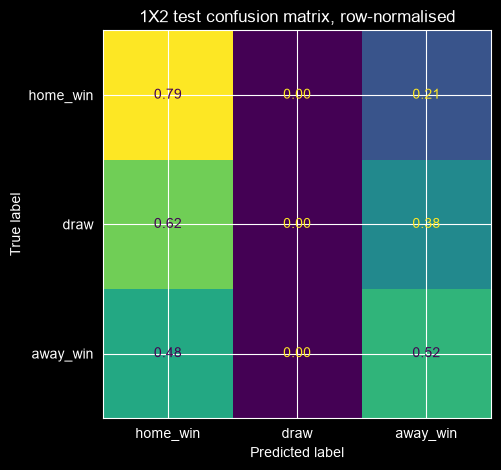

1X2 class-level test metrics


,precision,recall,f1-score,support
home_win,0.534,0.794,0.639,506.000
draw,0.000,0.000,0.000,286.000
away_win,0.469,0.519,0.493,360.000
accuracy,0.511,0.511,0.511,0.511
macro avg,0.334,0.438,0.377,1152.000
weighted avg,0.381,0.511,0.434,1152.000


Either-half test metrics (calibrated probabilities, 0.5 cut)


,target,accuracy,log_loss,positive_rate
0,home_wins_either_half,0.6389,0.6357,0.5851
1,away_wins_either_half,0.6189,0.6732,0.4583


Decision summary on the test set (tuned thresholds)


,decision,picks,coverage,precision
0,home,204,0.177,0.686
1,away,13,0.011,0.769
2,home win either half,59,0.051,0.729
3,away win either half,28,0.024,0.679
4,combined slate,304,0.264,0.697
5,skip,848,0.736,NaN


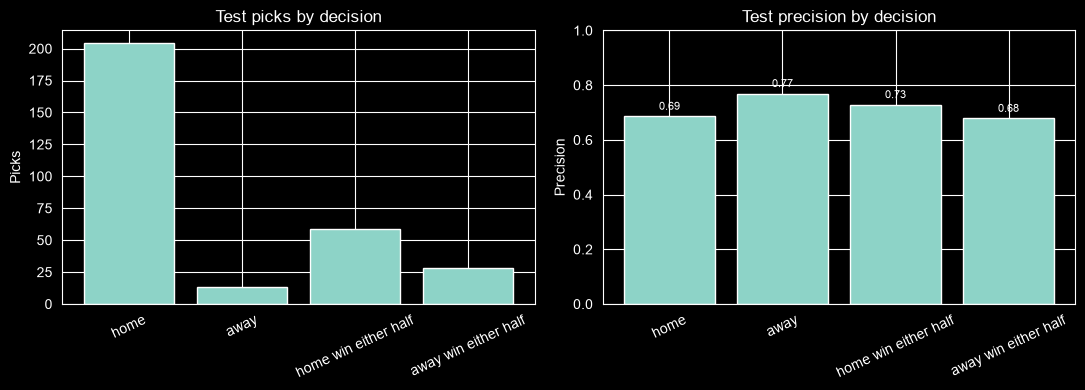

Highest-confidence test decisions


,date_utc,competition,home_team,away_team,home_win_probability,draw_probability,away_win_probability,home_wins_either_half_probability,away_wins_either_half_probability,decision,decision_probability,bet_won
813,2026-04-11 16:30:00,La Liga,barcelona,espanyol,0.893,0.053,0.054,0.947,0.156,home,0.893,True
458,2026-02-21 20:05:00,Ligue 1,psg,metz,0.887,0.058,0.055,0.941,0.156,home,0.887,True
165,2026-01-21 20:00:00,UEFA Champions League,bayern_munich,royale_union_sg,0.887,0.059,0.054,0.919,0.152,home,0.887,True
217,2026-01-25 15:15:00,La Liga,barcelona,oviedo,0.880,0.062,0.058,0.941,0.134,home,0.880,True
250,2026-01-28 20:00:00,UEFA Champions League,arsenal,kairat_almaty,0.858,0.077,0.065,0.926,0.156,home,0.858,True
192,2026-01-24 14:30:00,Bundesliga,bayern_munich,augsburg,0.857,0.077,0.066,0.910,0.237,home,0.857,False
443,2026-02-21 14:30:00,Bundesliga,bayern_munich,eintracht_frankfurt,0.856,0.076,0.067,0.911,0.230,home,0.856,True
82,2026-01-11 16:30:00,Bundesliga,bayern_munich,wolfsburg,0.854,0.079,0.067,0.916,0.258,home,0.854,True
709,2026-03-21 14:30:00,Bundesliga,bayern_munich,union_berlin,0.852,0.079,0.069,0.920,0.274,home,0.852,True
754,2026-04-04 14:15:00,La Liga,mallorca,real_madrid,0.177,0.174,0.650,0.300,0.850,away win either half,0.850,False


In [13]:
raw_test_probabilities = trained_models["match_result"].predict_proba(test_feature_matrix)
calibrated_test_probabilities = apply_match_result_calibration(raw_test_probabilities)

test_comparison_table = pandas.DataFrame([
    {
        "model": "class_frequency",
        **evaluate_multiclass_probabilities(
            test_matches["match_result"],
            class_frequency_probabilities(len(test_matches)),
        ),
    },
    {
        "model": "elo_only_logistic",
        **evaluate_multiclass_probabilities(
            test_matches["match_result"],
            elo_only_model.predict_proba(test_matches[["elo_difference"]]),
        ),
    },
    {
        "model": "xgboost_raw",
        **evaluate_multiclass_probabilities(test_matches["match_result"], raw_test_probabilities),
    },
    {
        "model": "xgboost_calibrated",
        **evaluate_multiclass_probabilities(test_matches["match_result"], calibrated_test_probabilities),
    },
])
print("1X2 test comparison against baselines")
display(test_comparison_table.round(4))

test_result_predictions = calibrated_test_probabilities.argmax(axis=1)
normalised_test_confusion = confusion_matrix(
    test_matches["match_result"],
    test_result_predictions,
    labels=[0, 1, 2],
    normalize="true",
)
confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=normalised_test_confusion,
    display_labels=result_label_order,
)
figure, axis = pyplot.subplots(figsize=(5.6, 4.8))
confusion_display.plot(ax=axis, values_format=".2f", colorbar=False)
axis.set_title("1X2 test confusion matrix, row-normalised")
pyplot.tight_layout()
pyplot.show()

print("1X2 class-level test metrics")
display(
    pandas.DataFrame(
        classification_report(
            test_matches["match_result"],
            test_result_predictions,
            labels=[0, 1, 2],
            target_names=result_label_order,
            output_dict=True,
            zero_division=0,
        )
    ).transpose().round(3)
)

print("Either-half test metrics (calibrated probabilities, 0.5 cut)")
either_half_test_records = []
for target_name in binary_target_names:
    calibrated_positive = apply_binary_calibration(
        trained_models[target_name].predict_proba(test_feature_matrix)[:, 1],
        either_half_calibrators[target_name],
    )
    either_half_test_records.append({
        "target": target_name,
        "accuracy": accuracy_score(test_matches[target_name], (calibrated_positive >= 0.5).astype(int)),
        "log_loss": log_loss(test_matches[target_name], calibrated_positive, labels=[0, 1]),
        "positive_rate": float(test_matches[target_name].mean()),
    })
display(pandas.DataFrame(either_half_test_records).round(4))

test_scored_matches = score_model_probabilities(test_matches, trained_models)
test_evaluation_table = apply_decisions(test_scored_matches, decision_thresholds)
decision_summary_table = summarize_decisions(test_evaluation_table)

print("Decision summary on the test set (tuned thresholds)")
display(decision_summary_table.round(3))

decision_plot_table = decision_summary_table[
    ~decision_summary_table["decision"].isin(["combined slate", "skip"])
].copy()

figure, axes = pyplot.subplots(1, 2, figsize=(11, 4))
axes[0].bar(decision_plot_table["decision"], decision_plot_table["picks"])
axes[0].set_title("Test picks by decision")
axes[0].set_ylabel("Picks")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(decision_plot_table["decision"], decision_plot_table["precision"])
axes[1].set_title("Test precision by decision")
axes[1].set_ylabel("Precision")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=25)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=3, fontsize=8)
pyplot.tight_layout()
pyplot.show()

print("Highest-confidence test decisions")
highest_confidence_decisions = (
    test_evaluation_table[test_evaluation_table["decision"].ne("skip")]
    .sort_values("decision_probability", ascending=False)
    [[
        "date_utc", "competition", "home_team", "away_team",
        "home_win_probability", "draw_probability", "away_win_probability",
        "home_wins_either_half_probability", "away_wins_either_half_probability",
        "decision", "decision_probability", "bet_won",
    ]]
    .head(15)
    .copy()
)
probability_column_names = highest_confidence_decisions.select_dtypes("number").columns
highest_confidence_decisions[probability_column_names] = (
    highest_confidence_decisions[probability_column_names].round(3)
)
display(highest_confidence_decisions)

## 14. Team-State Store and Fixture Prediction

A compact, serialisable snapshot of everything needed to predict an upcoming
fixture: final Elo ratings, each team's recent matches (all-venue and
venue-specific), and the full head-to-head history. `build_fixture_features`
reproduces the training features exactly with the same windows, minimums, and
rest-day cap. `predict_fixture` returns calibrated probabilities plus
the tuned decision. xG features fall back to missing when a team's recent
matches lack xG data, exactly as in training.

In [14]:
trained_team_names = sorted(
    set(training_matches["home_team"]).union(training_matches["away_team"])
)


def build_team_state_store(results_frame):
    if results_frame.empty:
        return {
            "team_elo_ratings": {},
            "team_form": {},
            "h2h_history": pandas.DataFrame(),
            "built_through": None,
        }

    history = results_frame.sort_values(["date_utc", "match_id"]).copy()
    _, team_elo_ratings = add_elo_features(history)
    history_team_rows = make_team_match_rows(history)

    team_form = {}
    for team_name, team_history in history_team_rows.groupby("team"):
        ordered_team_history = team_history.sort_values(["date_utc", "match_id"])
        team_form[team_name] = {
            "recent_matches": ordered_team_history.tail(long_window).copy(),
            "recent_home_matches": ordered_team_history[
                ordered_team_history["venue"].eq("home")
            ].tail(short_window).copy(),
            "recent_away_matches": ordered_team_history[
                ordered_team_history["venue"].eq("away")
            ].tail(short_window).copy(),
            "last_fixture_date": ordered_team_history["date_utc"].max(),
        }

    return {
        "team_elo_ratings": team_elo_ratings,
        "team_form": team_form,
        "h2h_history": history_team_rows[
            ["team", "opponent", "date_utc", "result", "goal_difference"]
        ].copy(),
        "built_through": history["date_utc"].max(),
    }


def validate_known_teams(home_team, away_team, known_team_names=trained_team_names):
    unknown_team_names = [
        team_name
        for team_name in [home_team, away_team]
        if team_name not in known_team_names
    ]
    if unknown_team_names:
        raise ValueError(
            "Cannot predict fixtures for team names that were not present in training data: "
            + ", ".join(unknown_team_names)
        )


def state_mean(team_state_store, team_name, history_bucket, metric_name,
               window=short_window, minimum_matches=None, required=True):
    if minimum_matches is None:
        minimum_matches = window
    recent_history = team_state_store["team_form"].get(team_name, {}).get(history_bucket)
    if recent_history is None:
        available_values = pandas.Series(dtype=float)
    else:
        available_values = pandas.to_numeric(
            recent_history[metric_name].tail(window), errors="coerce"
        ).dropna()
    if len(available_values) < minimum_matches:
        if required:
            raise ValueError(
                f"Cannot build {metric_name} for {team_name}: fewer than {minimum_matches} "
                f"usable matches in {history_bucket}."
            )
        return float("nan")
    return float(available_values.mean())


def state_rest_days(team_state_store, team_name, fixture_date):
    last_fixture_date = team_state_store["team_form"].get(team_name, {}).get("last_fixture_date")
    if last_fixture_date is None or pandas.isna(last_fixture_date):
        raise ValueError(f"Cannot build rest days for {team_name}: no previous fixture found.")
    return min(float((fixture_date - last_fixture_date).days), maximum_rest_days)


def state_head_to_head(team_state_store, home_team, away_team):
    h2h_history = team_state_store["h2h_history"]
    if h2h_history.empty:
        return 0.0, float("nan"), float("nan")
    previous_meetings = h2h_history[
        h2h_history["team"].eq(home_team) & h2h_history["opponent"].eq(away_team)
    ]
    if previous_meetings.empty:
        return 0.0, float("nan"), float("nan")
    return (
        float(len(previous_meetings)),
        float(previous_meetings["result"].mean()),
        float(previous_meetings["goal_difference"].mean()),
    )


def build_fixture_features(home_team, away_team, date, time="15:00",
                           european_cup=False, team_state_store=None):
    validate_known_teams(home_team, away_team)

    if team_state_store is None:
        team_state_store = build_team_state_store(matches)

    fixture_date = pandas.to_datetime(f"{date} {time}", errors="coerce")
    if pandas.isna(fixture_date):
        fixture_date = pandas.to_datetime(date)

    elo_ratings = team_state_store["team_elo_ratings"]
    missing_elo_team_names = [
        team_name for team_name in [home_team, away_team] if team_name not in elo_ratings
    ]
    if missing_elo_team_names:
        raise ValueError(
            "Cannot build Elo features without stored ratings for: "
            + ", ".join(missing_elo_team_names)
        )
    home_elo = float(elo_ratings[home_team])
    away_elo = float(elo_ratings[away_team])

    def short_form(team_name, metric_name):
        return state_mean(team_state_store, team_name, "recent_matches", metric_name)

    def long_form(team_name, metric_name):
        return state_mean(
            team_state_store, team_name, "recent_matches", metric_name,
            window=long_window, minimum_matches=long_window_minimum_matches,
        )

    def xg_form(team_name, metric_name):
        return state_mean(
            team_state_store, team_name, "recent_matches", metric_name,
            window=xg_window, minimum_matches=xg_window_minimum_matches, required=False,
        )

    h2h_matches_played, h2h_home_win_rate, h2h_home_goal_difference = state_head_to_head(
        team_state_store, home_team, away_team,
    )

    fixture_feature_values = {
        "elo_difference": home_elo - away_elo,
        "home_elo": home_elo,
        "away_elo": away_elo,
        "home_points_at_home": state_mean(team_state_store, home_team, "recent_home_matches", "points"),
        "away_points_at_away": state_mean(team_state_store, away_team, "recent_away_matches", "points"),
        "home_goals_scored_form": short_form(home_team, "goals_scored"),
        "away_goals_scored_form": short_form(away_team, "goals_scored"),
        "points_form_difference": short_form(home_team, "points") - short_form(away_team, "points"),
        "home_attack_vs_away_defence": (
            short_form(home_team, "goals_scored") - short_form(away_team, "goals_conceded")
        ),
        "away_attack_vs_home_defence": (
            short_form(away_team, "goals_scored") - short_form(home_team, "goals_conceded")
        ),
        "goal_difference_form_gap": (
            short_form(home_team, "goal_difference") - short_form(away_team, "goal_difference")
        ),
        "long_points_form_difference": (
            long_form(home_team, "points") - long_form(away_team, "points")
        ),
        "long_goal_difference_form_gap": (
            long_form(home_team, "goal_difference") - long_form(away_team, "goal_difference")
        ),
        "shots_on_target_difference": (
            short_form(home_team, "shots_on_target") - short_form(away_team, "shots_on_target")
        ),
        "shots_on_target_conceded_difference": (
            short_form(home_team, "shots_on_target_conceded")
            - short_form(away_team, "shots_on_target_conceded")
        ),
        "shot_accuracy_difference": (
            short_form(home_team, "shot_accuracy") - short_form(away_team, "shot_accuracy")
        ),
        "corners_difference": short_form(home_team, "corners") - short_form(away_team, "corners"),
        "possession_difference": (
            short_form(home_team, "possession") - short_form(away_team, "possession")
        ),
        "fouls_difference": short_form(home_team, "fouls") - short_form(away_team, "fouls"),
        "rest_days_difference": (
            state_rest_days(team_state_store, home_team, fixture_date)
            - state_rest_days(team_state_store, away_team, fixture_date)
        ),
        "is_european_cup": int(european_cup),
        "h2h_matches_played": h2h_matches_played,
        "h2h_home_win_rate": h2h_home_win_rate,
        "h2h_home_goal_difference": h2h_home_goal_difference,
        "home_xg_for_form": xg_form(home_team, "expected_goals_for"),
        "away_xg_for_form": xg_form(away_team, "expected_goals_for"),
        "home_xg_against_form": xg_form(home_team, "expected_goals_against"),
        "away_xg_against_form": xg_form(away_team, "expected_goals_against"),
        "home_finishing_luck_form": xg_form(home_team, "finishing_luck"),
        "away_finishing_luck_form": xg_form(away_team, "finishing_luck"),
    }
    return pandas.DataFrame([fixture_feature_values])[feature_names]


def predict_fixture(home_team, away_team, date, time="15:00", european_cup=False,
                    team_state_store=None, models_by_target=None):
    validate_known_teams(home_team, away_team)

    if team_state_store is None:
        team_state_store = build_team_state_store(matches)
    if models_by_target is None:
        models_by_target = trained_models

    fixture_features = build_fixture_features(
        home_team,
        away_team,
        date,
        time=time,
        european_cup=european_cup,
        team_state_store=team_state_store,
    )

    result_probabilities = predict_match_result_probabilities(
        models_by_target["match_result"],
        fixture_features,
        calibrated=True,
    ).iloc[0].to_dict()
    probability_values = {**result_probabilities}
    for target_name in binary_target_names:
        raw_positive = float(models_by_target[target_name].predict_proba(fixture_features)[:, 1][0])
        probability_values[f"{target_name}_probability"] = float(
            apply_binary_calibration(numpy.array([raw_positive]), either_half_calibrators[target_name])[0]
        )

    decision = make_decision(
        probability_values["home_win_probability"],
        probability_values["draw_probability"],
        probability_values["away_win_probability"],
        probability_values["home_wins_either_half_probability"],
        probability_values["away_wins_either_half_probability"],
        decision_thresholds,
    )

    return pandas.DataFrame([{
        "date": pandas.to_datetime(date).date(),
        "time": time,
        "home_team": home_team,
        "away_team": away_team,
        **probability_values,
        **decision,
    }])


predict_fixture("lens", "lyon", "2026-08-15")

,date,time,home_team,away_team,home_win_probability,draw_probability,away_win_probability,home_wins_either_half_probability,away_wins_either_half_probability,decision,decision_probability
0,2026-08-15,15:00,lens,lyon,0.514944,0.236549,0.248507,0.662624,0.381658,skip,NaN


## 15. Historical Fixture Demo

Sanity check that the fixture path reproduces the training features: predict
a handful of test-window fixtures using only data available before each
kickoff, and compare against what actually happened.

In [15]:
demo_candidate_fixtures = matches[matches["date_utc"] >= test_split_date].head(10)
demo_predictions = []

for fixture_record in demo_candidate_fixtures.itertuples(index=False):
    if len(demo_predictions) == 5:
        break
    try:
        state_before_fixture = build_team_state_store(
            matches[matches["date_utc"] < fixture_record.date_utc]
        )
        prediction = predict_fixture(
            fixture_record.home_team,
            fixture_record.away_team,
            fixture_record.date_utc.strftime("%Y-%m-%d"),
            fixture_record.date_utc.strftime("%H:%M"),
            european_cup=bool(fixture_record.is_european_cup),
            team_state_store=state_before_fixture,
        )
    except ValueError as fixture_error:
        print(f"Skipping {fixture_record.home_team} vs {fixture_record.away_team}: {fixture_error}")
        continue
    prediction["competition"] = fixture_record.competition
    prediction["actual_match_result"] = match_result_labels[fixture_record.match_result]
    prediction["actual_home_wins_either_half"] = fixture_record.home_wins_either_half
    prediction["actual_away_wins_either_half"] = fixture_record.away_wins_either_half
    demo_predictions.append(prediction)

historical_fixture_demo = (
    pandas.concat(demo_predictions, ignore_index=True)
    if demo_predictions
    else pandas.DataFrame()
)

print("Historical fixture prediction demo")
display(historical_fixture_demo)

Skipping sunderland vs manchester_city: Cannot predict fixtures for team names that were not present in training data: sunderland
Historical fixture prediction demo


,date,time,home_team,away_team,home_win_probability,draw_probability,away_win_probability,home_wins_either_half_probability,away_wins_either_half_probability,decision,decision_probability,competition,actual_match_result,actual_home_wins_either_half,actual_away_wins_either_half
0,2026-01-01,17:30,crystal_palace,fulham,0.551784,0.223825,0.224391,0.661388,0.352408,skip,NaN,Premier League,draw,1,1
1,2026-01-01,17:30,liverpool,leeds,0.750364,0.155512,0.094124,0.828729,0.281304,home,0.750364,Premier League,draw,0,0
2,2026-01-01,20:00,brentford,tottenham,0.386674,0.266367,0.346959,0.572323,0.517117,skip,NaN,Premier League,draw,0,0
3,2026-01-02,19:45,toulouse,lens,0.324499,0.281874,0.393627,0.445660,0.512796,skip,NaN,Ligue 1,away_win,0,1
4,2026-01-02,19:45,cagliari,ac_milan,0.240282,0.236463,0.523256,0.355737,0.657964,skip,NaN,Serie A,away_win,0,1


## 16. Save Artifact

Everything needed to score a fixture elsewhere: the three models, the
Platt calibrators, the tuned decision thresholds, the feature lists and
windows, the team-state store built from the full dataset, and the
evaluation tables for provenance.

In [16]:
team_state_store = build_team_state_store(matches)

artifact = {
    "model_family": "XGBClassifier",
    "model_setup": "one multiclass 1X2 model plus two binary either-half models, "
                   "Platt-calibrated, with validation-tuned decision thresholds",
    "xgboost_parameters": xgboost_parameters,
    "selected_max_depth": best_max_depth,
    "selected_min_child_weight": best_min_child_weight,
    "trained_models": trained_models,
    "match_result_calibrator": match_result_calibrator,
    "either_half_calibrators": either_half_calibrators,
    "feature_names": feature_names,
    "core_feature_names": core_feature_names,
    "nan_tolerant_feature_names": nan_tolerant_feature_names,
    "target_names": target_names,
    "binary_target_names": binary_target_names,
    "match_result_labels": match_result_labels,
    "decision_thresholds": decision_thresholds,
    "short_window": short_window,
    "long_window": long_window,
    "long_window_minimum_matches": long_window_minimum_matches,
    "xg_window": xg_window,
    "xg_window_minimum_matches": xg_window_minimum_matches,
    "minimum_team_matches": minimum_team_matches,
    "maximum_rest_days": maximum_rest_days,
    "initial_elo": initial_elo,
    "elo_k": elo_k,
    "home_advantage": home_advantage,
    "european_cup_names": european_cup_names,
    "validation_split_date": validation_split_date,
    "test_split_date": test_split_date,
    "trained_team_names": trained_team_names,
    "team_state_store": team_state_store,
    "sweep_table": sweep_table,
    "model_metric_table": model_metric_table,
    "validation_baseline_table": validation_baseline_table,
    "test_comparison_table": test_comparison_table,
    "threshold_tuning_table": threshold_tuning_table,
    "decision_summary_table": decision_summary_table,
    "test_evaluation_table": test_evaluation_table,
    "feature_importance_table": feature_importance_table,
    "team_filter_summary": team_filter_summary,
    "load_summary": load_summary,
    "data_path": str(data_path),
}

models_directory.mkdir(parents=True, exist_ok=True)
joblib.dump(artifact, artifact_path)
reloaded_artifact = joblib.load(artifact_path)

print(f"Saved artifact to {artifact_path}")
print("Reloaded artifact keys:", sorted(reloaded_artifact.keys()))
print("Reloaded model setup:", reloaded_artifact["model_setup"])
print("Reloaded feature count:", len(reloaded_artifact["feature_names"]))
print("Reloaded decision thresholds:", reloaded_artifact["decision_thresholds"])

Saved artifact to C:\PROJECTS\Python\ML\betting\models\match_1x2_pred.joblib
Reloaded artifact keys: ['binary_target_names', 'core_feature_names', 'data_path', 'decision_summary_table', 'decision_thresholds', 'either_half_calibrators', 'elo_k', 'european_cup_names', 'feature_importance_table', 'feature_names', 'home_advantage', 'initial_elo', 'load_summary', 'long_window', 'long_window_minimum_matches', 'match_result_calibrator', 'match_result_labels', 'maximum_rest_days', 'minimum_team_matches', 'model_family', 'model_metric_table', 'model_setup', 'nan_tolerant_feature_names', 'selected_max_depth', 'selected_min_child_weight', 'short_window', 'sweep_table', 'target_names', 'team_filter_summary', 'team_state_store', 'test_comparison_table', 'test_evaluation_table', 'test_split_date', 'threshold_tuning_table', 'trained_models', 'trained_team_names', 'validation_baseline_table', 'validation_split_date', 'xg_window', 'xg_window_minimum_matches', 'xgboost_parameters']
Reloaded model setup: